In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder,StandardScaler, MinMaxScaler, LabelEncoder

In [28]:
df = pd.read_csv('telco.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
df.drop('customerID', axis= 1, inplace= True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset='TotalCharges', inplace=True)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == "Yes" else 0)
df['gender'] = df['gender'].map(lambda x: 1 if x =="Male" else 0)
df['Partner']= df['Partner'].map(lambda x: 1 if x =="Yes" else 0)
df['Dependents'] = df['Dependents'].map(lambda x: 1 if x =="Yes" else 0)
df['PhoneService'] = df['PhoneService'].map(lambda x: 1 if x =="Yes" else 0)

In [30]:
df_copy = df.copy()

In [33]:
df_copy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# Encoding

In [31]:
label_enc = LabelEncoder()
df['PaymentMethod'] = label_enc.fit_transform(df[['PaymentMethod']])
df['InternetService'] = label_enc.fit_transform(df[['DeviceProtection']])
df['OnlineSecurity'] = label_enc.fit_transform(df[['OnlineSecurity']])
df['OnlineBackup'] = label_enc.fit_transform(df[['OnlineBackup']])
df['PaperlessBilling'] = label_enc.fit_transform(df[['PaperlessBilling']])
df['StreamingMovies'] = label_enc.fit_transform(df[['StreamingMovies']])
df['StreamingTV'] = label_enc.fit_transform(df[['StreamingTV']])
df['TechSupport'] = label_enc.fit_transform(df[['TechSupport']])
df['DeviceProtection'] = label_enc.fit_transform(df[['DeviceProtection']])
df['MultipleLines'] = label_enc.fit_transform(df[['MultipleLines']])

ord_encoder = OrdinalEncoder()
df['Contract'] = ord_encoder.fit_transform(df[['Contract']])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

In [36]:
one_encoder.fit_transform(df_copy[['PaymentMethod']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7032 stored elements and shape (7032, 4)>

In [37]:
one_encoder = OneHotEncoder()
cols_to_encode = [
    'PaymentMethod', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'PaperlessBilling', 'StreamingMovies', 'StreamingTV', 'TechSupport',
    'DeviceProtection', 'MultipleLines'
]

one_encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = one_encoder.fit_transform(df_copy[cols_to_encode])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=one_encoder.get_feature_names_out(cols_to_encode),
    index=df_copy.index
)

df_copy = df_copy.drop(columns=cols_to_encode).join(encoded_df)

ord_encoder = OrdinalEncoder()
df_copy['Contract'] = ord_encoder.fit_transform(df_copy[['Contract']])

# Baseline

### Label

In [63]:
X =  df.drop('Churn', axis = 1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=3000)

In [8]:
score = cross_val_score(model, X_train, y_train, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.006541642486390794
Mean Accuracy: 0.8028444444444445


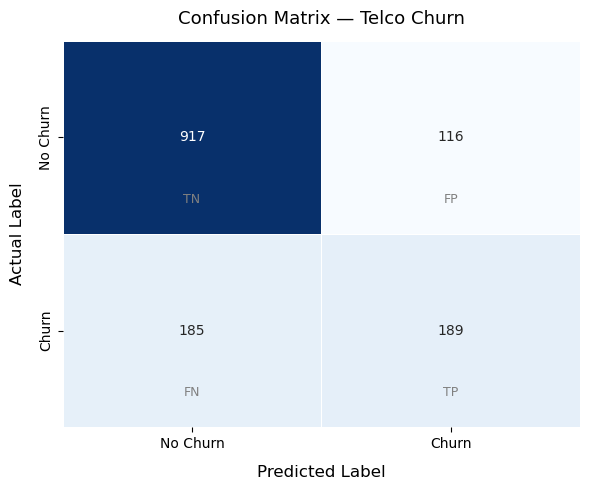


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [9]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

### OneHOt

In [59]:
X =  df_copy.drop('Churn', axis = 1)
y = df_copy['Churn']

X_train_copy, X_test_copy, y_train_copy, y_test_copy = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=3000)

In [61]:
score = cross_val_score(model, X_train_copy, y_train_copy, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.011122127871727715
Mean Accuracy: 0.8051555555555556


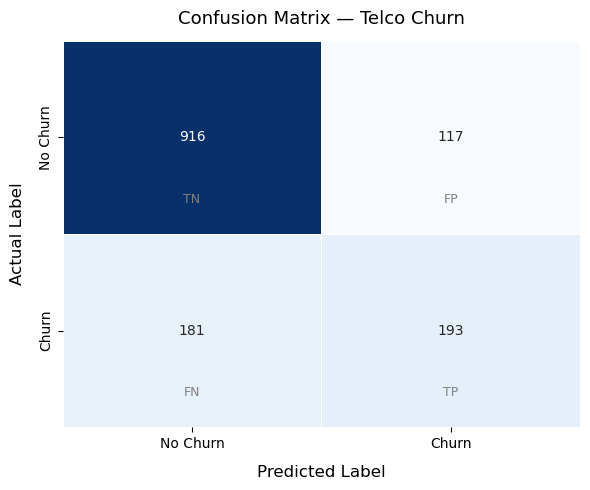


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [46]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_copy, y_train_copy)
y_pred_copy = model.predict(X_test_copy)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test_copy, y_pred_copy)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

# With Scaling

### Label

In [10]:
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
robust_scaler = RobustScaler()


X_train_scaled_standart = std_scaler.fit_transform(X_train)
X_test_scaled_standart = std_scaler.transform(X_test)

X_train_scaled_minmax = min_max_scaler.fit_transform(X_train)
X_test_scaled_minmax = min_max_scaler.transform(X_test)

X_train_scaled_robust = robust_scaler.fit_transform(X_train)
X_test_scaled_robust = robust_scaler.transform(X_test)

In [11]:
score = cross_val_score(model, X_train_scaled_standart, y_train, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.006168658337030199
Mean Accuracy: 0.8024888888888888


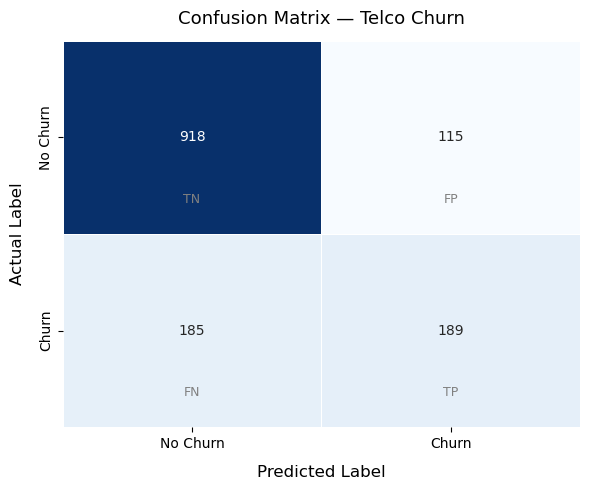


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [12]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_scaled_standart, y_train)
y_pred = model.predict(X_test_scaled_standart)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

In [13]:
score = cross_val_score(model, X_train_scaled_minmax, y_train, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.008518505636061114
Mean Accuracy: 0.8030222222222221


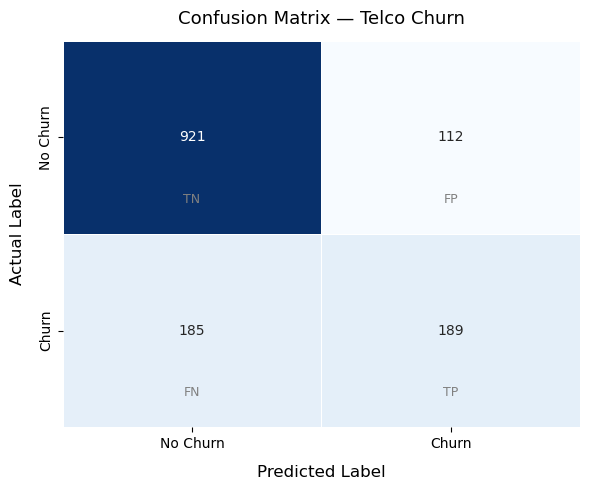


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [14]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_scaled_minmax, y_train)
y_pred = model.predict(X_test_scaled_minmax)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

In [15]:
score = cross_val_score(model, X_train_scaled_robust, y_train, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.007168656054633199
Mean Accuracy: 0.8032


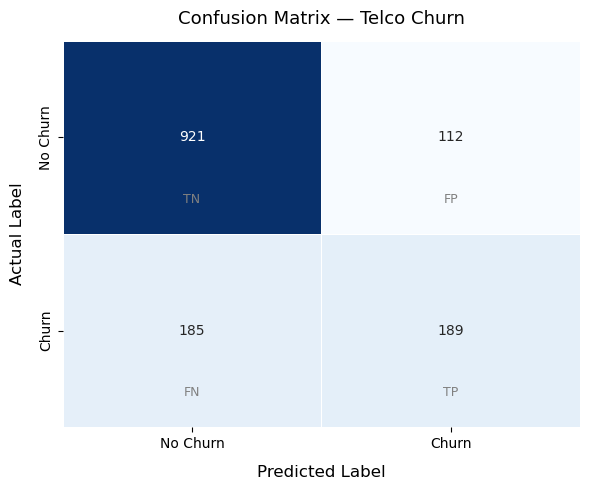


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [16]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_scaled_robust, y_train)
y_pred = model.predict(X_test_scaled_robust)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

### OneHot

In [47]:
X_train_scaled_standart = std_scaler.fit_transform(X_train_copy)
X_test_scaled_standart = std_scaler.transform(X_test_copy)

X_train_scaled_minmax = min_max_scaler.fit_transform(X_train_copy)
X_test_scaled_minmax = min_max_scaler.transform(X_test_copy)

X_train_scaled_robust = robust_scaler.fit_transform(X_train_copy)
X_test_scaled_robust = robust_scaler.transform(X_test_copy)

In [48]:
score = cross_val_score(model, X_train_scaled_standart, y_train_copy, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.011124969135759671
Mean Accuracy: 0.8056888888888889


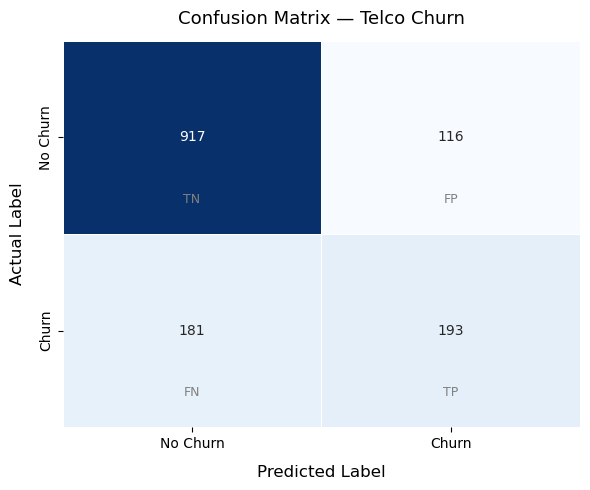


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [56]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_scaled_standart, y_train_copy)
y_pred_copy = model.predict(X_test_scaled_standart)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test_copy, y_pred_copy)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test_copy, y_pred_copy, target_names=labels))

In [50]:
score = cross_val_score(model, X_train_scaled_minmax, y_train_copy, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.010775738638714108
Mean Accuracy: 0.8033777777777777


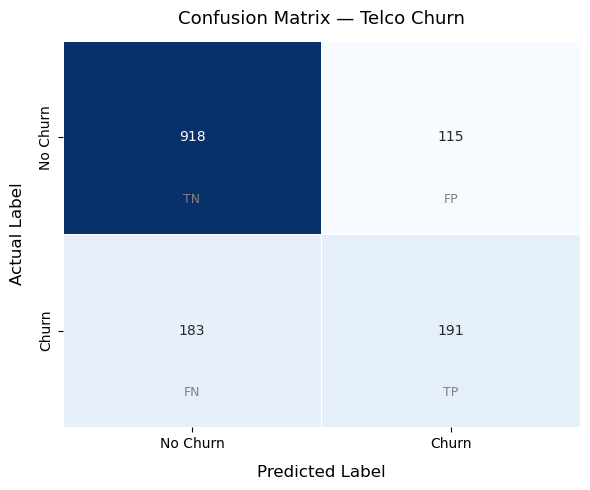


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [57]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_scaled_minmax, y_train_copy)
y_pred_copy = model.predict(X_test_scaled_minmax)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test_copy, y_pred_copy)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test_copy, y_pred_copy, target_names=labels))

In [54]:
score = cross_val_score(model, X_train_scaled_robust, y_train_copy, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.011053718440326986
Mean Accuracy: 0.8049777777777777


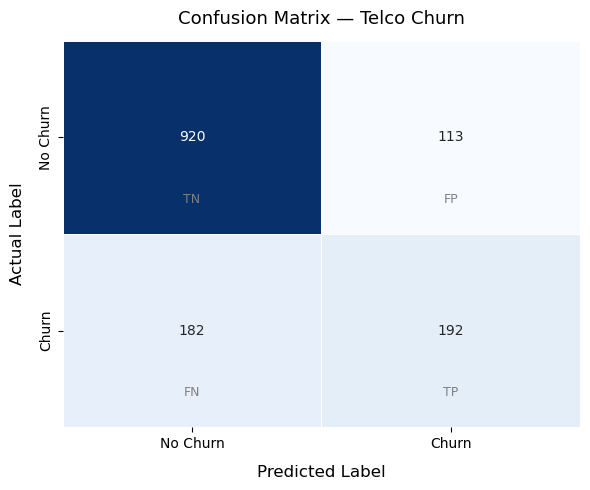


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [55]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_scaled_robust, y_train_copy)
y_pred_copy = model.predict(X_test_scaled_robust)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test_copy, y_pred_copy)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test_copy, y_pred_copy, target_names=labels))

In [66]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

# Feature Selection

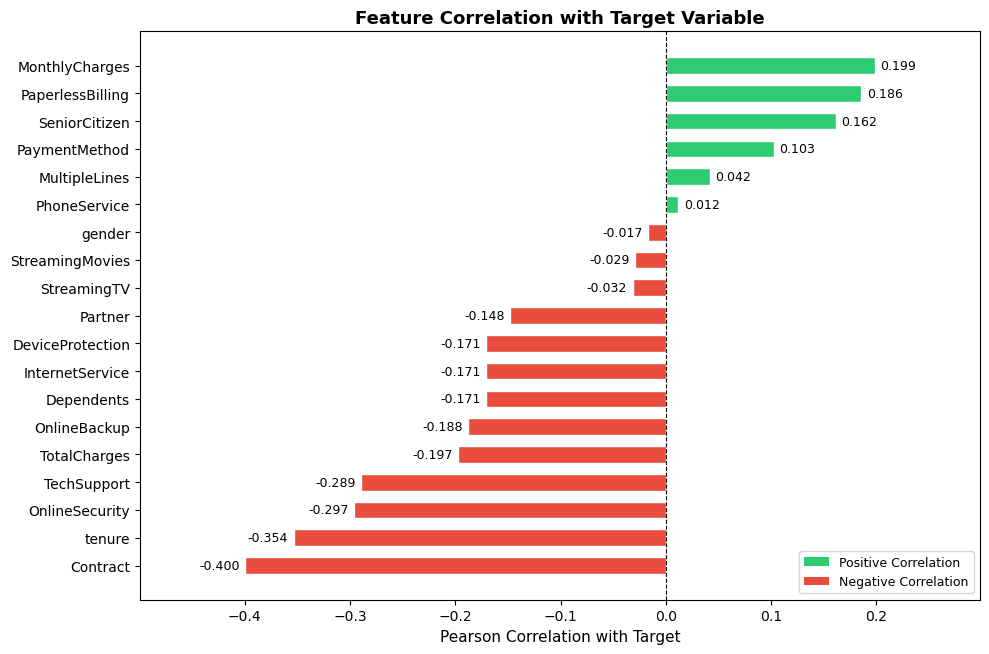

In [64]:
corr_series = (
    pd.concat([X_train, y_train], axis=1)
    .corr()[y_train.name]          
    .drop(y_train.name)            
    .sort_values(ascending=True)   
)

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_series]

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_series) * 0.35)))
bars = ax.barh(corr_series.index, corr_series.values, color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, corr_series.values):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Pearson Correlation with Target", fontsize=11)
ax.set_title("Feature Correlation with Target Variable", fontsize=13, fontweight="bold")
ax.set_xlim(corr_series.min() - 0.1, corr_series.max() + 0.1)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Positive Correlation"),
    Patch(facecolor="#e74c3c", label="Negative Correlation"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


In [67]:
X_train_fs = X_train.drop(['MultipleLines', 'PhoneService', 'gender', 'StreamingMovies', 'StreamingTV'], axis =1)
X_test_fs = X_test.drop(['MultipleLines', 'PhoneService', 'gender', 'StreamingMovies', 'StreamingTV'], axis =1)

In [70]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=3000)

In [71]:
score = cross_val_score(model, X_train_fs, y_train, cv=kfold, scoring = 'accuracy')
print("Standard Deviasion Accuracy:", np.std(score))
print("Mean Accuracy:", np.mean(score))

Standard Deviasion Accuracy: 0.013475977712531373
Mean Accuracy: 0.8012444444444444


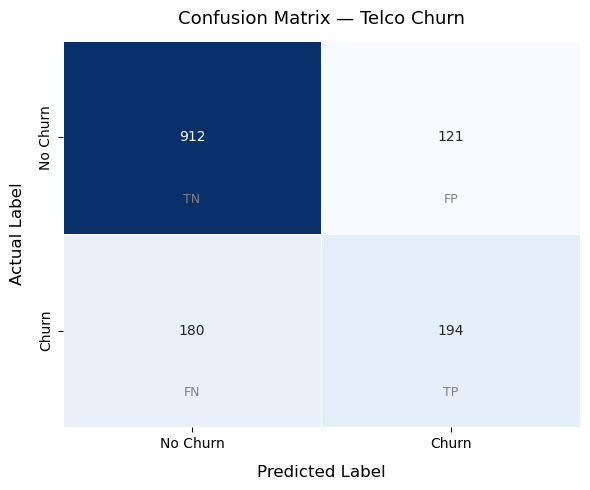


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [72]:
# ── Fit model & prediksi ──────────────────────────────────────────
model.fit(X_train_fs, y_train)
y_pred = model.predict(X_test_fs)

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
labels = ['No Churn', 'Churn']

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Telco Churn', fontsize=13, pad=12)

# Anotasi manual per sel (TP, FP, FN, TN)
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(
            j + 0.5, i + 0.82,
            cell_labels[i][j],
            ha='center', va='center',
            fontsize=9, color='gray'
        )

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report ─────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

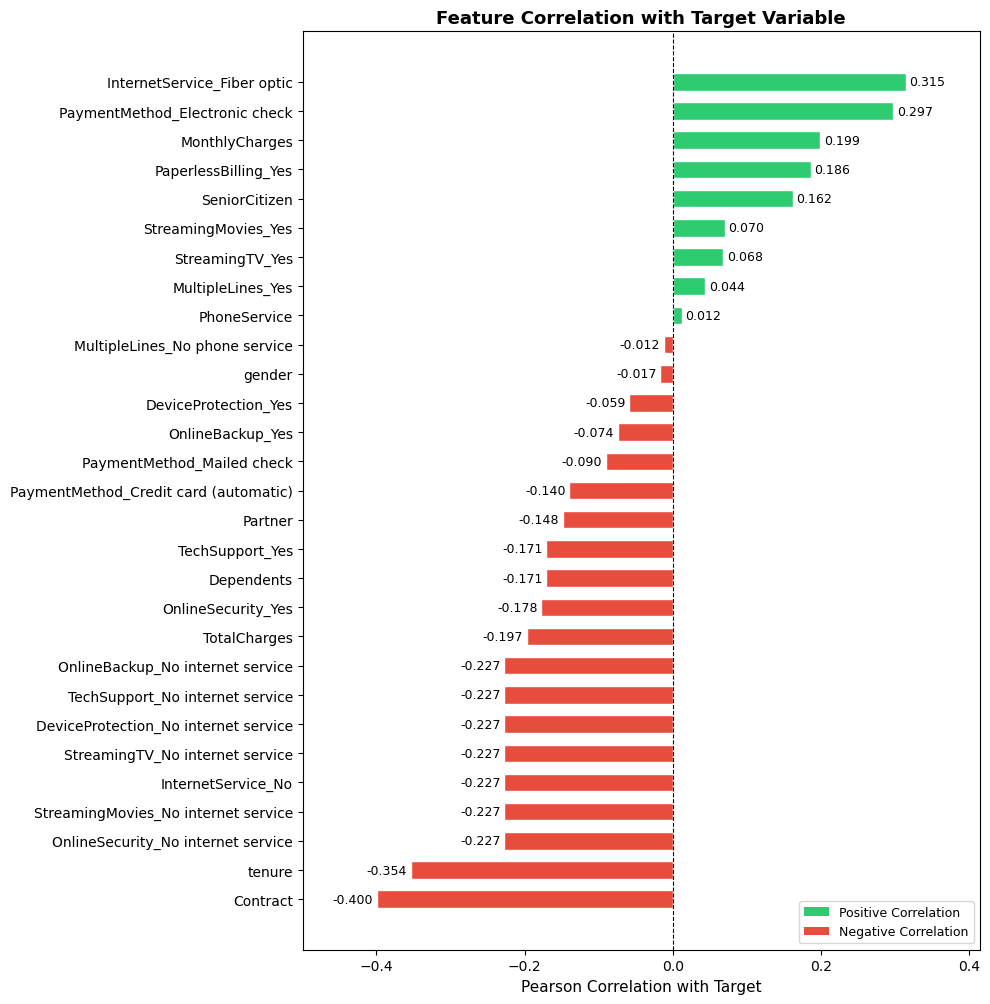

In [65]:
corr_series = (
    pd.concat([X_train_copy, y_train_copy], axis=1)
    .corr()[y_train.name]          
    .drop(y_train.name)            
    .sort_values(ascending=True)   
)

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_series]

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_series) * 0.35)))
bars = ax.barh(corr_series.index, corr_series.values, color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, corr_series.values):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Pearson Correlation with Target", fontsize=11)
ax.set_title("Feature Correlation with Target Variable", fontsize=13, fontweight="bold")
ax.set_xlim(corr_series.min() - 0.1, corr_series.max() + 0.1)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="Positive Correlation"),
    Patch(facecolor="#e74c3c", label="Negative Correlation"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
X_train_fs_copy = X_train_copy.drop([], axis =1)
X_test_fs_copy = X_test_copy.drop([], axis =1)

In [ ]:
corr_series = (
    pd.concat([X_train_copy, y_train_copy], axis=1)
    .corr()[y_train.name]          
    .drop(y_train.name)            
    .sort_values(ascending=True)   
)

corr_series.reset_index(inplace=True)

,index,Churn
0,Contract,-0.399703
1,tenure,-0.353649
2,OnlineSecurity_No internet service,-0.227342
3,StreamingMovies_No internet service,-0.227342
4,InternetService_No,-0.227342
5,StreamingTV_No internet service,-0.227342
6,DeviceProtection_No internet service,-0.227342
7,TechSupport_No internet service,-0.227342
8,OnlineBackup_No internet service,-0.227342
9,TotalCharges,-0.197139


In [20]:
train =  df.drop('Churn', axis = 1)
test = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(train, test, test_size=0.2, random_state=42)